In [1]:
# https://github.com/onnx/models/tree/main/validated/vision/style_transfer/fast_neural_style

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# loading input and resize if needed
PATH_TO_IMAGE="/home/jovyan/scratch-volume/models/mosaic/amber.jpg"

image = Image.open(PATH_TO_IMAGE)

# size_reduction_factor = 1
# image = image.resize(
#    (int(image.size[0] / size_reduction_factor),
#     int(image.size[1] / size_reduction_factor)),
#    Image.Resampling.LANCZOS
# )

image = image.resize((224, 224), Image.Resampling.LANCZOS)


# Preprocess image
x = np.array(image).astype('float32')
x = np.transpose(x, [2, 0, 1])
x = np.expand_dims(x, axis=0)

In [2]:
x.shape

(1, 3, 224, 224)

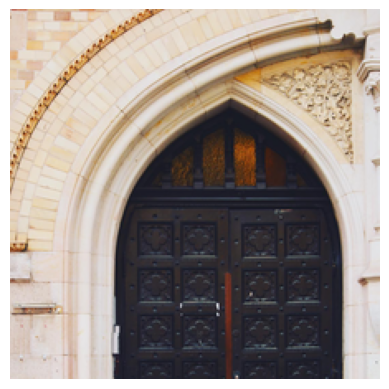

In [3]:
# Remove batch dimension: (1, 3, H, W) -> (3, H, W)
img = x[0]

# Convert from CHW to HWC: (3, H, W) -> (H, W, 3)
img = np.transpose(img, (1, 2, 0))

# Convert to uint8 if pixel values are in 0-255 range
img = img.astype(np.uint8)

plt.imshow(img)
plt.axis("off")
plt.show()

In [4]:
!pip install onnxruntime

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import onnxruntime as ort

PATH_TO_MODEL="/home/jovyan/scratch-volume/models/mosaic/mosaic-9.onnx"

session = ort.InferenceSession(
    PATH_TO_MODEL,
    providers=["CPUExecutionProvider"]
)

In [11]:
output_name = session.get_outputs()[0].name
input_name = session.get_inputs()[0].name
y = session.run([output_name], {input_name: x})[0]

# x should already be:
# shape = (1, 3, H, W)
# dtype = float32


print("Output shape:", y.shape)

Output shape: (1, 3, 224, 224)


In [12]:
# Remove batch dimension
img = y[0]


# CHW -> HWC
img = np.transpose(img, (1, 2, 0))

# Clip values to valid image range
img = np.clip(img, 0, 255)

# Convert to uint8
img = img.astype(np.uint8)

stylized = Image.fromarray(img)


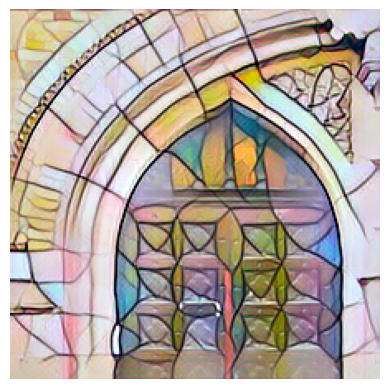

In [13]:
plt.imshow(stylized)
plt.axis("off")
plt.show()